# The Seoul Bike Sharing Demand problem

The dataset contains count of public bicycles rented per hour in the Seoul Bike Sharing System, with corresponding weather data and holiday information

We want to predict the bike count required at each hour for a stable supply of rental bikes. 

More information on https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

The variables in the dataset are:

* `Date`: year-month-day
* `Rented Bike count`: Count of bikes rented at each hour
* `Hour`: Hour of he day
* `Temperature`: Temperature in Celsius
* `Humidity`: %
* `Windspeed`: m/s
* `Visibility`: 10m
* `Dew point temperature`: Celsius 
* `Solar radiation`: MJ/m2
* `Rainfall`: mm
* `Snowfall`: cm
* `Seasons`: Winter, Spring, Summer, Autumn
* `Holiday`: Holiday/No holiday
* `Functional Day`: NoFunc(Non Functional Hours), Fun(Functional hours)

Of these we will drop the `Date` variable and use `Rented bike count` as the target.  
Moreover:
* the variable `Seasons` is categorical with values `'Autumn', 'Spring', 'Summer', 'Winter'`, which we will transform into the integer values `0, 1, 2, 3`.
* the variables `Holiday` and `Functioning Day`	are binary with values `'Holiday', 'No Holiday'` and `'No', 'Yes'` respectively and we will transform both into the integer values `0, 1`.

You can download the dataset using   
    `ds = fetch_ucirepo(id=560)`  
and save it as a joblib file with, for instance, `joblib.dump(ds, 'seoul_bikes.joblib')`.

Before proceeding to select the final variables study the downloaded

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import joblib

# from sklearnex import patch_sklearn
# patch_sklearn()

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

from sklearn.model_selection import KFold, GridSearchCV, train_test_split

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

import seaborn as sns

from ucimlrepo import fetch_ucirepo 

In [3]:
from sklearn.exceptions import ConvergenceWarning

import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Downloading the dataset 

You can download the dataset using   

    `ds = fetch_ucirepo(id=560)`  

and save it as a joblib file with, for instance, `joblib.dump(ds, 'seoul_bikes.joblib')`.

In [4]:
downloading = True
if downloading:
    ds = fetch_ucirepo(id=560)
    joblib.dump(ds, 'seoul_bikes.joblib')

Before proceeding to select the final variables, study the downloaded data with commands such as the ones below

In [5]:
ds = joblib.load('seoul_bikes.joblib')
print('''ds['data'] keys:\t''', ds['data'].keys())

print('\nvariables')
display(ds['variables'])

df_data = ds['data']['original']
print('\nsome data values')
display(df_data.head())

ds['data'] keys:	 dict_keys(['ids', 'features', 'targets', 'original', 'headers'])

variables


,name,role,type,demographic,description,units,missing_values
0,Date,Feature,Date,None,None,None,no
1,Rented Bike Count,Feature,Integer,None,None,None,no
2,Hour,Feature,Integer,None,None,None,no
3,Temperature,Feature,Continuous,None,None,C,no
4,Humidity,Feature,Integer,None,None,%,no
5,Wind speed,Feature,Continuous,None,None,m/s,no
6,Visibility,Feature,Integer,None,None,10m,no
7,Dew point temperature,Feature,Continuous,None,None,C,no
8,Solar Radiation,Feature,Continuous,None,None,Mj/m2,no
9,Rainfall,Feature,Integer,None,None,mm,no



some data values


,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


### Data Processing and Variable and Target Selection

In [6]:
# Configuration parameters
visualization = True
test_set_percent = 0.5
random_state = 123
n_splits = 5

In [7]:
# Put here your data processing code
# At the end, x and y must be numpy matrices with the variable and target values that have been selected

# we drop date and use rented bike count as target
df = df_data.copy()
y = df['Rented Bike Count'].values

df = df.drop(columns=['Date'])

# the variable `Seasons` has the values `Winter, Spring, Summer, Autumn` and we will transform them into the integer values `0, 1, 2, 3` respectively.
df['Seasons'] = df['Seasons'].map({'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3})

# the variables `Holiday` and `Functioning Day`	are binary with values `'Holiday', 'No Holiday'` and `'No', 'Yes'` respectively and we will transform both into the integer values `0, 1`.
df['Holiday'] = df['Holiday'].map({'Holiday': 1, 'No Holiday': 0})
df['Functioning Day'] = df['Functioning Day'].map({'Yes': 1, 'No': 0})

x = df.drop(columns=['Rented Bike Count']).values

# we scale x and y
scaler_x = StandardScaler()
x = scaler_x.fit_transform(x)

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

print(x.shape, y.shape)

df

(8760, 12) (8760,)


,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,0,1
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,0,1
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,0,1
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,0,1
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,3,0,1
8756,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,3,0,1
8757,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,3,0,1
8758,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,3,0,1


In [8]:
df.describe()

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068,1.504110,0.049315,0.966324
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746,1.114408,0.216537,0.180404
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000,2.000000,0.000000,1.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000,2.000000,0.000000,1.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000,3.000000,1.000000,1.000000


### Data Analysis

Boxplots, scatterplots, histograms, correlations, ...

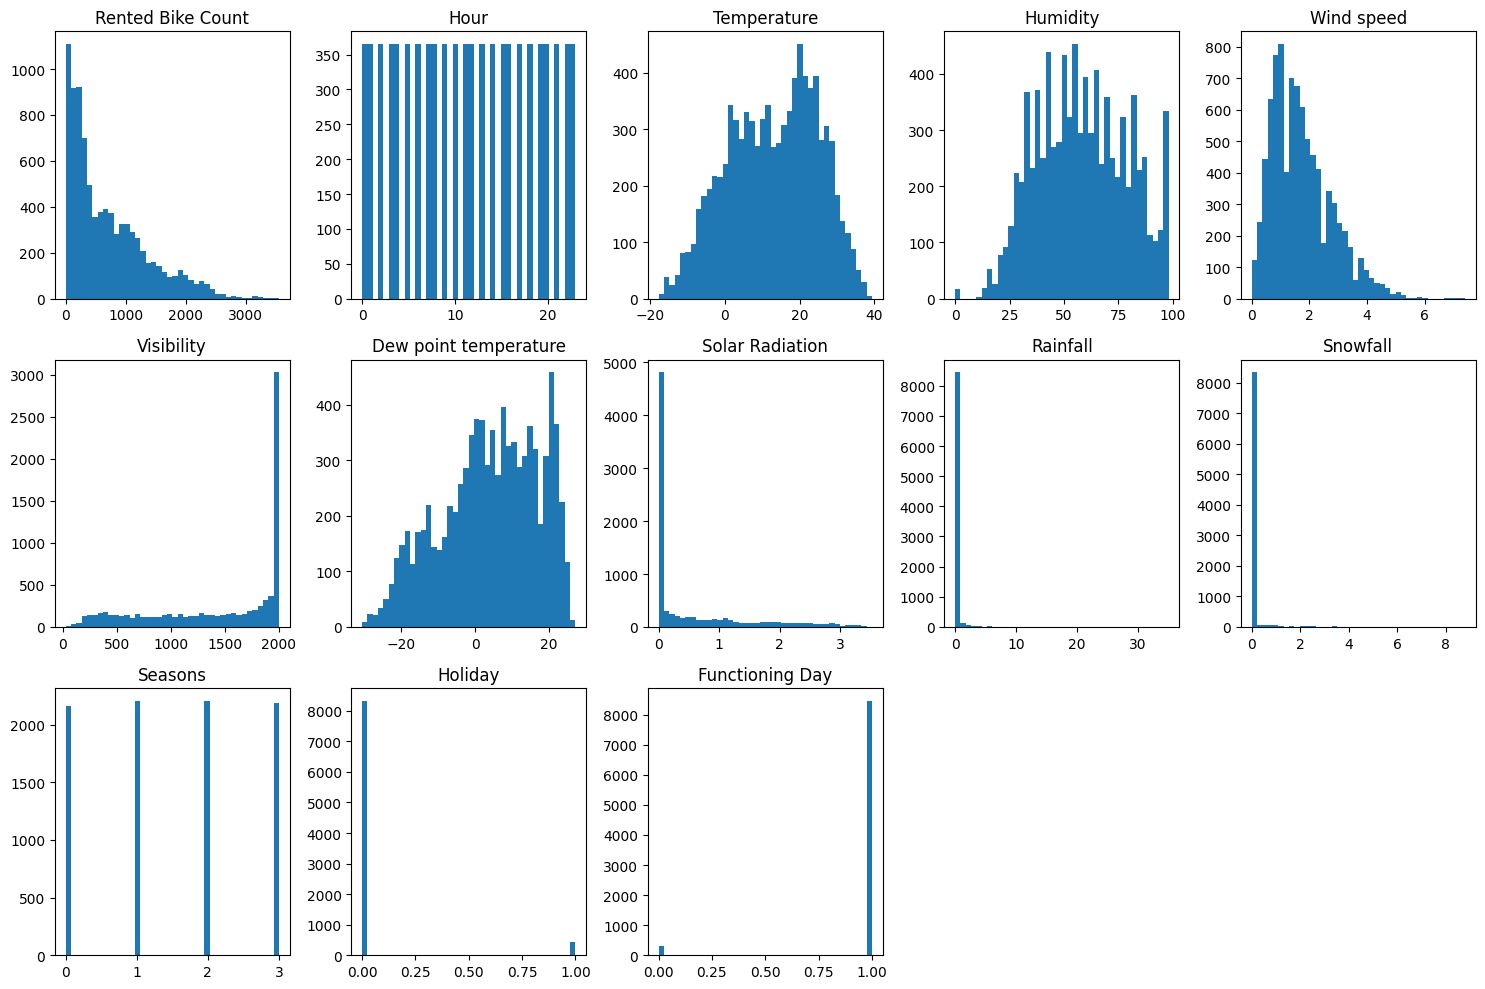

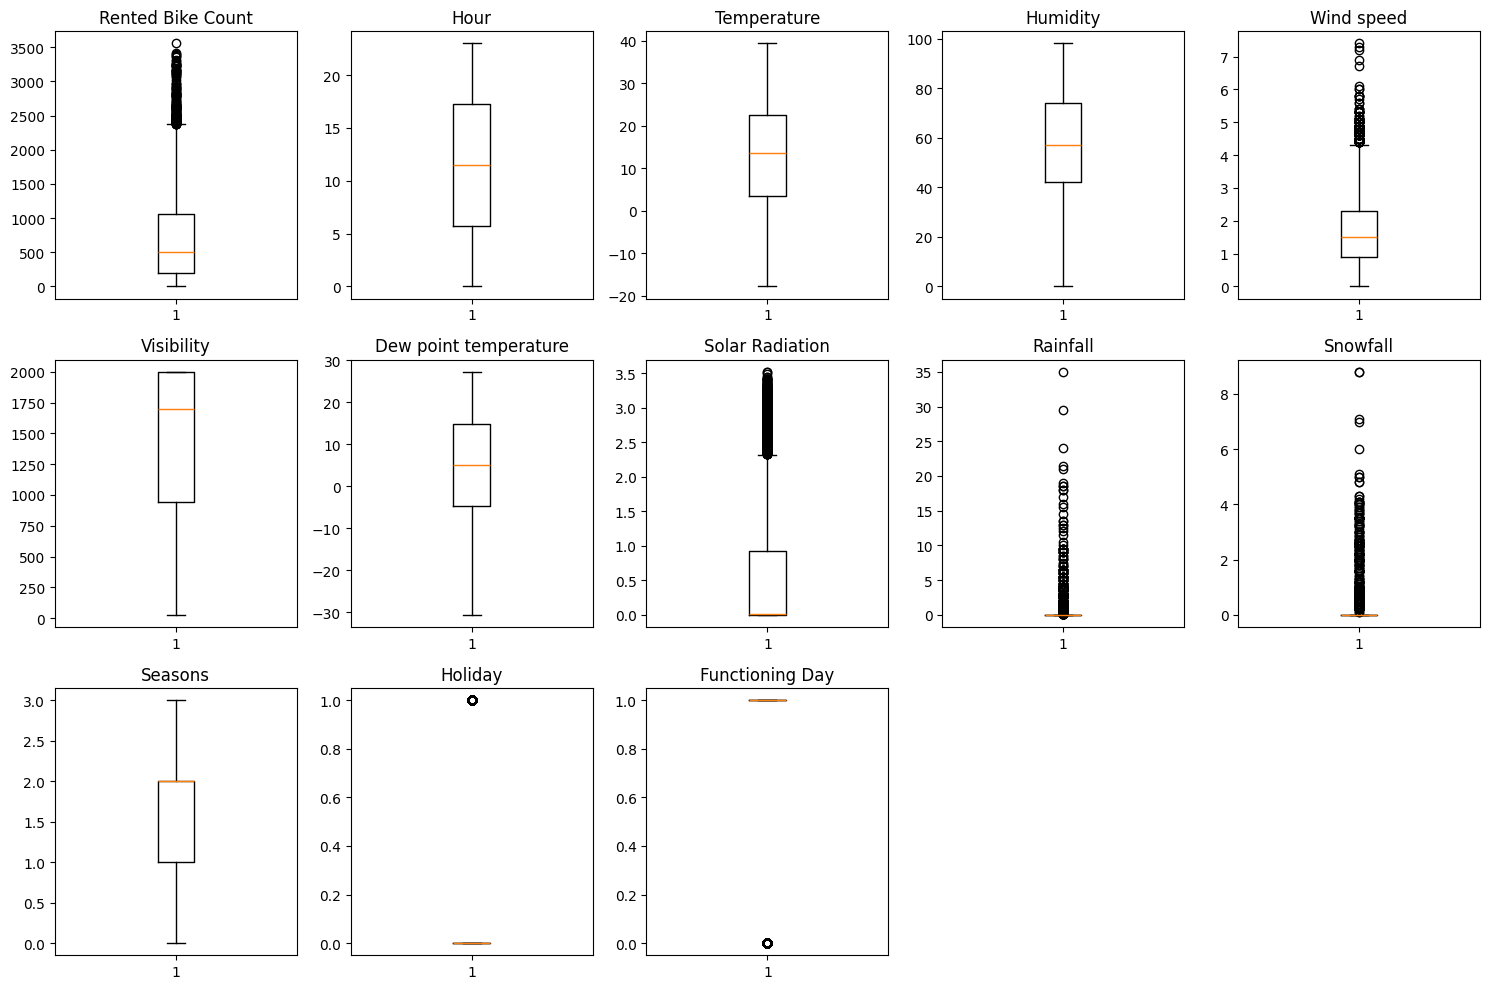

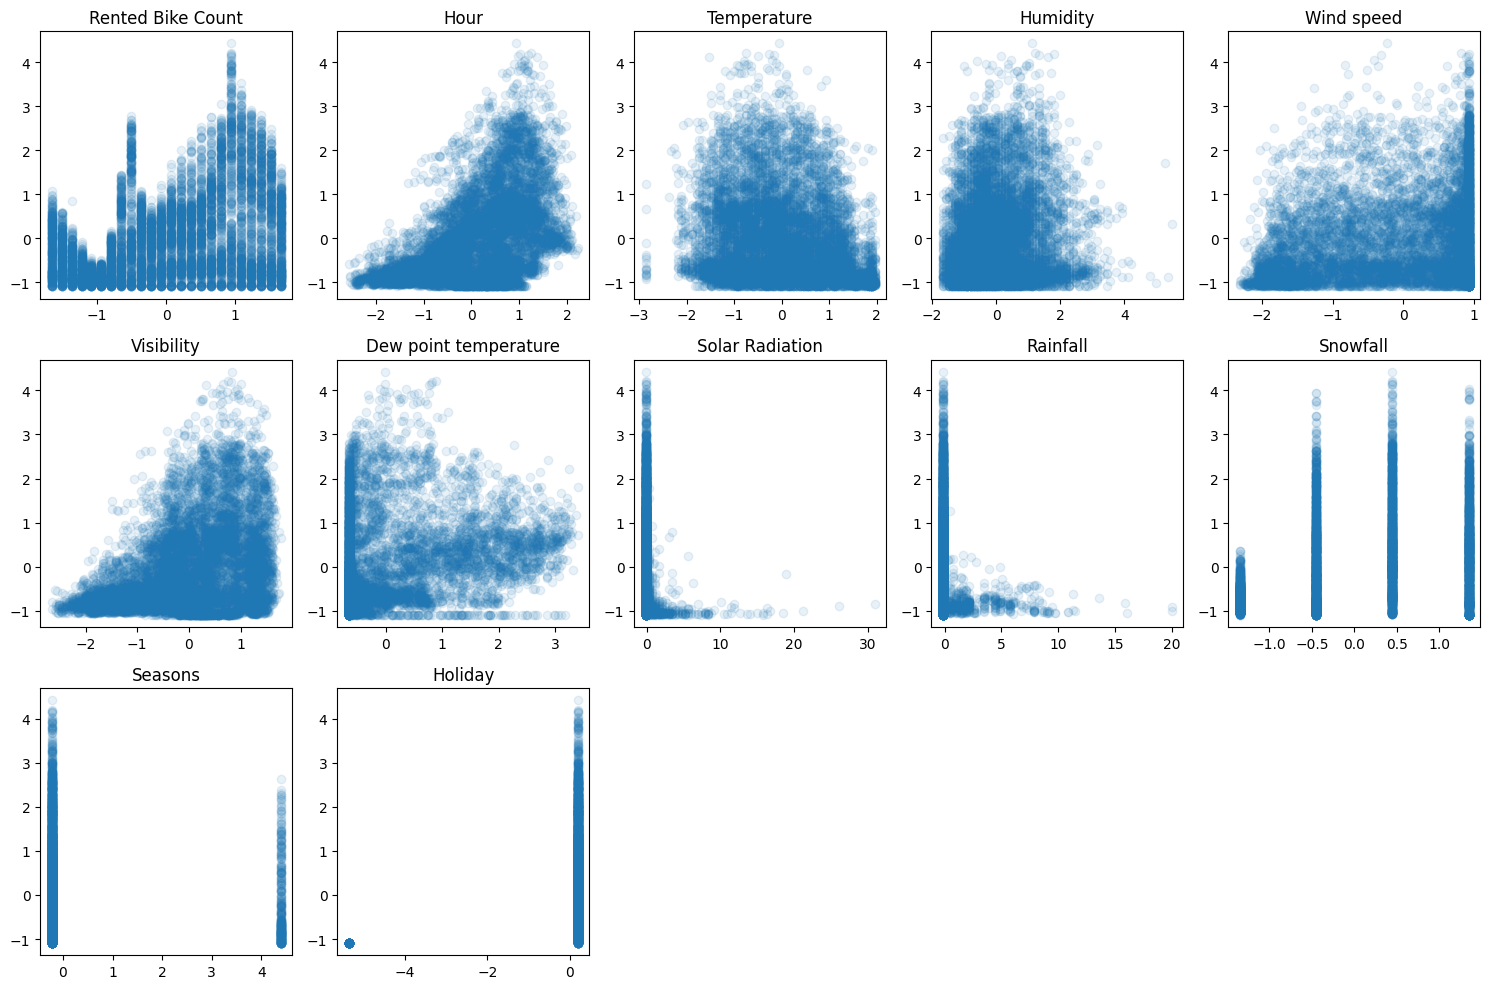

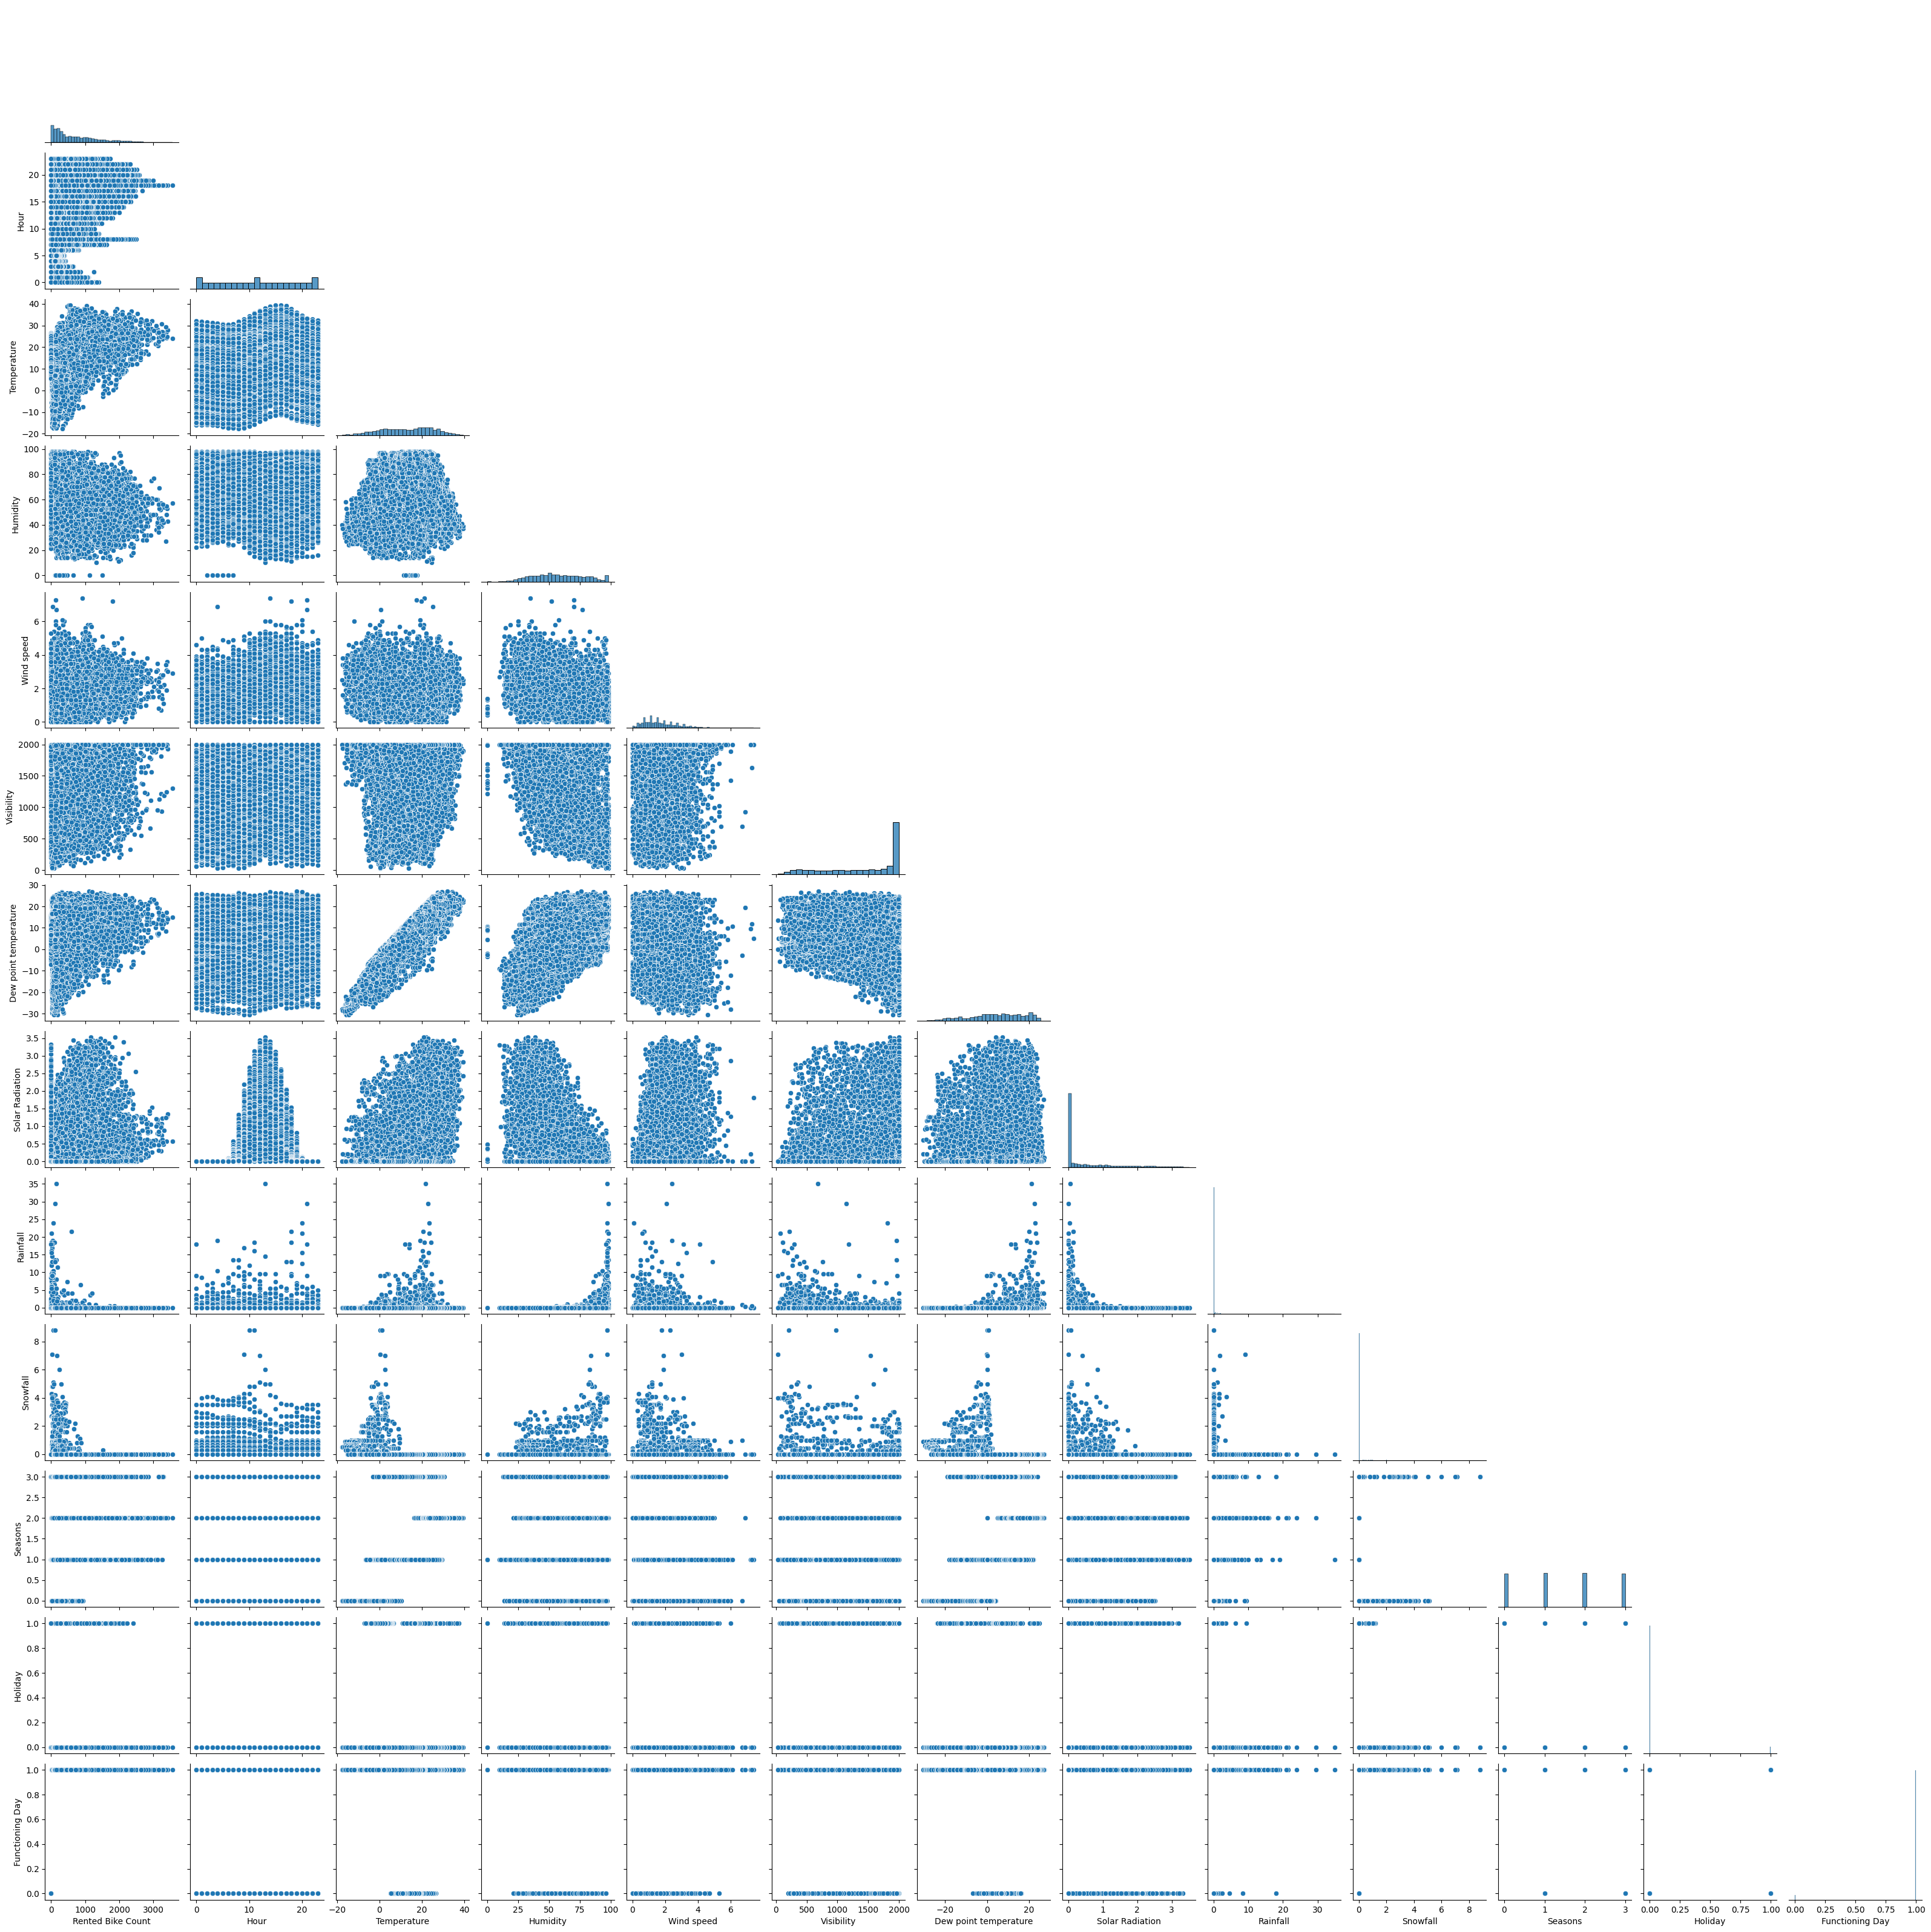

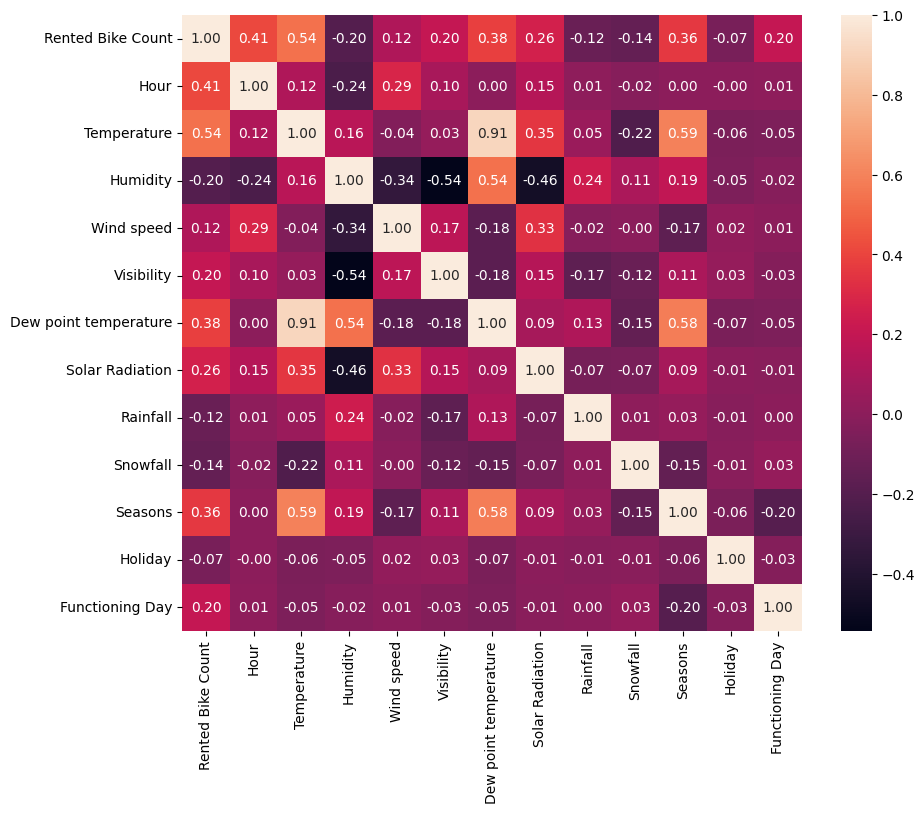

In [9]:
# visualization of the data

if visualization:
    # histograms
    plt.figure(figsize=(15, 10))
    for i in range(df.shape[1]):
        plt.subplot(3, 5, i+1)
        plt.hist(df.iloc[:, i], bins=40)
        plt.title(df.columns[i])
    plt.tight_layout()
    plt.show()

    # boxplots
    plt.figure(figsize=(15, 10))
    for i in range(df.shape[1]):
        plt.subplot(3, 5, i + 1)
        plt.boxplot(df.iloc[:, i])
        plt.title(df.columns[i])
    plt.tight_layout()
    plt.show()

    # scatter plots
    plt.figure(figsize=(15, 10))
    for i in range(x.shape[1]):
        plt.subplot(3, 5, i + 1)
        plt.scatter(x[:, i], y, alpha=0.1)
        plt.title(df.columns[i])
    plt.tight_layout()
    plt.show()

    # pairplot
    sns.pairplot(df, corner=True)
    plt.show()

    # correlation heatmap
    corr = df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f")
    plt.show()

### Data Analysis Conclusions

- Como se puede ver en la grafica anterior, existe una correlacion de 0.54 entre Rented Bike Count y la temperatura, lo que dice que a medida que la temperatura va subiendo, las personas alquilan mas bicicletas,lo que es logico ya que en una epoca de frio las personas no optan por ir bicicleta por la baja temperatura.

- Tambien existe una correlacion de 0.41, que es Rented Bike Count con Hour, lo que refleja que seria nuestra segunda correlacion mas fuerte, con esto se podria decir que a horas por la tarde tiene mas alquileres que las tempranas.

- Seguidamente si relacionamos seasons con una correlacion de 0.36 y Dew Point temperature 0.38 con Rented Bike Count, las dos muestran que hay una correlacion dentro del rango moderadom donde reflejaria que en las estaciones mas calientes o calidas tienen mas demanda la renta de las bicicletas.

Ahora bien, que pasa con los resultados con correlacion alta:

- La variable temperatura y Dew point temperature tiene una correlacion de 0.91, lo cual es muy alta pero esto es debido a que practicamente le estamos dando la misma informacion dos veces al modelo,esto hay que tomarlo en consideracion ya que este valor causaria inestabilidad en el modelo lo cual dificultaria la interpretacion de resultados.

- Otras dos variables que tiene una correlacion del mas del 0.5 es Seasons y temperatura, esto es logico por lo que es muy obvio que la estacion diga la temperatura o viceversa.

- Y finalmente humidity con Visibility (-0.54) esta igual es logico por que a mas humedad (niebla) hay menor visibilidad.

### Data Analysis Conclusions

- As can be seen in the graph above, there is a correlation of 0.54 between Rented Bike Count and temperature, indicating that as the temperature rises, more people rent bicycles. This is logical, since people are less likely to cycle during cold weather due to the low temperatures.

- There is also a correlation of 0.41 between Rented Bike Count and Time of Day, which is our second strongest correlation. This suggests that there are more rentals in the afternoon than in the morning.

- Furthermore, when we examine the correlation between seasons (0.36) and Dew Point temperature (0.38) with Rented Bike Count, both show a moderate correlation, indicating that bike rentals are more in demand during warmer seasons.

Now, what about the results with high correlations

- The variables temperature and dew point temperature have a correlation of 0.91, which is very high. However, this is because we are essentially giving the model the same information twice. This must be taken into consideration, as this value would cause instability in the model, making it difficult to interpret the results.

- Two other variables with a correlation greater than 0.5 are seasons and temperature. This is logical, as it's quite obvious that the season would indicate the temperature, or vice versa.

- Finally, humidity and visibility (-0.54) are also correlated, which is logical because higher humidity (fog) results in lower visibility.

### Train-test splits

We will split the dataset into train and test subsets, with the test set size being 20% of the train set size.

In [10]:
# Split the data into training and testing subsets
# x, y are numpy matrices with the variable and target values that have been selected before
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_set_percent, random_state=random_state)   

kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

## Ridge Regression

### Optimal `alpha` Selection and Analysis

In [11]:
# select alpha in ridge regression by CV

# Put here your code for ridge model definition, param_grid definition, and grid search fitting and analysis

ridge_model = Ridge()

param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]}

cv = GridSearchCV(estimator=ridge_model, param_grid=param_grid, cv=kf)

cv.fit(x_train, y_train)

print('Best alpha:', cv.best_params_['alpha'])

Best alpha: 10.0


- El resultado aqui nos dio 10.0 lo cual nos dice claramente que nuestro modelo necesita ser regularizado para evitar el sobrejuste, es decir que debemos poner una penalizacion alta para que funciones mejor

The result here was 10.0, which clearly tells us that our model needs to be regularized to avoid overfitting; that is, we must apply a high penalty for it to work better.

### Testing the Best Ridge Model

In [12]:
# After testing the final ridge model on the test set, save its test set predictions for further comparison

print("R^2 on test set:", cv.score(x_test, y_test))

y_pred_ridge = cv.predict(x_test)
print("MAE on test set:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE on test set:", mean_squared_error(y_test, y_pred_ridge))

R^2 on test set: 0.5376248408428745
MAE on test set: 0.5085946036039952
MSE on test set: 0.45789738822880505


- El primer resultado R^2 de 0.537 nos dice de que el modelo con las caracteristicas empleadas, puede explicar el 54 % de la demanda de las bicicletas.

- The first result R^2 of 0.537 tells us that the model with the characteristics used can explain 54% of the demand for bicycles.

## MLPs

### Optimal `alpha` Selection and Analysis

In [13]:
# Choose an appropriate MLP architecture jusifying your choice and select the MLP alpha by CV

# Put here your code for MLP model definition, param_grid definition, and grid search fitting and analysis

# we have 12 inputs from which we first go up to 24 hidden units in the first layer, then down to 6 hidden units in the second layer
# the idea is to first increase the representation capacity and then reduce it to force the network to learn compact representations
mlp_model = MLPRegressor(hidden_layer_sizes=[24, 6])

param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]}

cv = GridSearchCV(estimator=mlp_model, param_grid=param_grid, cv=kf)

cv.fit(x_train, y_train)

print('Best alpha:', cv.best_params_['alpha'])

Best alpha: 0.1


Here, obtaining 0.1 as the best alpha would be right in the middle, which tells us that we are at an optimal performance level

### Testing the Best MLP Model

In [14]:
# After testing the final model on the test set, build a 10 MLP ensemble with the optimal configuration and save its test set predictions for further comparison

print('R^2 on test set with single MLP:', cv.score(x_test, y_test))
y_pred_mlp = cv.predict(x_test)
print("MAE on test set with single MLP:", mean_absolute_error(y_test, y_pred_mlp))
print("MSE on test set with single MLP:", mean_squared_error(y_test, y_pred_mlp))

# build ensemble of 10 MLPs with best params
mlp_ensemble = []
for i in range(10):
    mlp = MLPRegressor(hidden_layer_sizes=[24, 6], alpha=cv.best_params_['alpha'], random_state=random_state + i)
    mlp.fit(x_train, y_train)
    mlp_ensemble.append(mlp)

# predict by averaging predictions from ensemble members
y_pred_ensemble = np.mean([mlp.predict(x_test) for mlp in mlp_ensemble], axis=0)

# evaluate ensemble
r2_ensemble = r2_score(y_test, y_pred_ensemble)
print('R^2 on test set with MLP ensemble:', r2_ensemble)
print("MAE on test set with MLP ensemble:", mean_absolute_error(y_test, y_pred_ensemble))
print("MSE on test set with MLP ensemble:", mean_squared_error(y_test, y_pred_ensemble))

R^2 on test set with single MLP: 0.7883250624805663
MAE on test set with single MLP: 0.31088496585362363
MSE on test set with single MLP: 0.20962501796232252
R^2 on test set with MLP ensemble: 0.8144572275832789
MAE on test set with MLP ensemble: 0.2807438633228896
MSE on test set with MLP ensemble: 0.18374592408732113


Con los resultados obtenidos se comprueba lo siguiente:
- MLP es superior a Ridge, ya que aqui se obtuvo 0.79 lo cual es superior al 0.54 del Ridge, con ello podemos decir que la relacion de los datos son no lineales (el modelo lineal no es suficiente)
- En cuanto al MLP ensemple (0.81), este es superior al MLP individual (0.79), lo que nos dice que el MLP ensemble es el mejor hasta ahora ya que explica el 81% de la demanda de las bicicletas.

The results obtained confirm the following:
- MLP is superior to Ridge, since here we obtained 0.79, which is higher than Ridge's 0.54. Therefore, we can say that the relationship between the data is non-linear (the linear model is not sufficient).
- Regarding the ensemble MLP (0.81), this is superior to the individual MLP (0.79), which tells us that the ensemble MLP is the best so far, as it explains 81% of the demand for bicycles.

## SVRs

### Optimal Hyperparameter Selection and Analysis

In [15]:
# Put here your code for SVR model definition, param_grid definition, and grid search fitting and analysis

svr_model = SVR()
param_grid = {'C': [0.1, 1.0, 10.0, 100.0], 'epsilon': [0.01, 0.1, 1.0] }
cv = GridSearchCV(estimator=svr_model, param_grid=param_grid, cv=kf)

cv.fit(x_train, y_train)

print(cv.best_params_)

{'C': 100.0, 'epsilon': 0.1}


### Testing the Best SVR Model

In [16]:
# After testing the final SVR model on the test set, save its test set predictions for further comparison

print('R^2 on test set:', cv.score(x_test, y_test))

y_pred_svr = cv.predict(x_test)

R^2 on test set: 0.820913642345027


## Comparing Ridge, MLP and SVR Models

In [17]:
# Put your comparison code here

models = ['Ridge', 'MLP Ensemble', 'SVR']

predictions = [y_pred_ridge, y_pred_ensemble, y_pred_svr]

for model, y_pred in zip(models, predictions):
    print(f'R^2 on test set with {model}: {r2_score(y_test, y_pred)}')
print('')
for model, y_pred in zip(models, predictions):
    print(f"MAE on test set with {model}: {mean_absolute_error(y_test, y_pred)}")
print('')
for model, y_pred in zip(models, predictions):
    print(f"MSE on test set with {model}: {mean_squared_error(y_test, y_pred)}")

R^2 on test set with Ridge: 0.5376248408428745
R^2 on test set with MLP Ensemble: 0.8144572275832789
R^2 on test set with SVR: 0.820913642345027

MAE on test set with Ridge: 0.5085946036039952
MAE on test set with MLP Ensemble: 0.2807438633228896
MAE on test set with SVR: 0.2608469259798249

MSE on test set with Ridge: 0.45789738822880505
MSE on test set with MLP Ensemble: 0.18374592408732113
MSE on test set with SVR: 0.17735203505981453


## Conclusions

#### Que encontramos

- Luego de todas las pruebas realizadas el modelos ganador seria el SVR ya que obtuvimos un rendimiento alto con un r2 de 0.821, un MAE de 0.261 y el MSE de 0.177.
- El modelo como se dijo anteriormente es no-lineal por lo que tanto el SVR Y MLP superaraon a Ridge, este solo llego a R2 = 0.54 (54%), mientras que los modelos no lineales llegaron al 81%.
- Para este modelo la tecnica mas exitosa seria ensemble. El MLP Ensemble R2 = 0.814 le gano al MLP individual que obtuvo R2 = 0.788, lo que confirma que es una tecnica efectiva para poder reducir el error y que el modelo sea mas estable . 

#### Posibles mejoras

- Una posible mejora podria ser poder mejorar el SVR, es decir, ejecutar el GridSearchCV para SVR pero esta vez con un rango de busqueda mas alto en el parametro, es probable que aumente el R2 al final.
- Dentro de los datos o se empleo la columna DATE lo que se podria usar y extraer informacion como el dia de la semanam mes o incluso si es fin de semana o no, para este ejercicio podria ser de mucha ayuda.

#### Probar nuevos modelos

- Otro modelo que se podria usar puede ser el de basados en arboles, como por ejemplo RandomForestRegressor o Gradient Boosting, seria importante aplicarlos que ya que estos no requieren datos tabulares.

- Por lo que SVR como el MLP Ensemble fue fuerte, se podria implementar StackingRegressor y asi poder usar los resultados de los dos modelos y obtener incluso un meta modelo final.


## Conclusions

#### What we found

- After all the tests performed, the winning model was SVR, as we obtained high performance with an R² of 0.821, an MAE of 0.261, and an MSE of 0.177.

- As mentioned previously, the model is non-linear, so both SVR and MLP outperformed Ridge, which only reached R² = 0.54 (54%), while the non-linear models reached 81%.

- For this model, the most successful technique was ensemble. The MLP Ensemble R² = 0.814 outperformed the individual MLP, which obtained R² = 0.788, confirming that it is an effective technique for reducing error and making the model more stable.

#### Possible Improvements

- One possible improvement could be to enhance the SVR model, specifically by running GridSearchCV for SVR with a higher search range parameter. This would likely increase the final R² value.

- The DATE column was not used in the data. This could be used to extract information such as the day of the week, month, or even whether it is a weekend. This would be very helpful for this exercise.

### Testing New Models

- Another model that could be used is a tree-based model, such as RandomForestRegressor or Gradient Boosting. It would be important to apply these models since they do not require tabular data.

- Given the strength of both SVR and MLP Ensemble, StackingRegressor could be implemented to combine the results of both models and even obtain a final meta-model.